# Cell Mosaic Demo

This notebook walks through the full `cell_mosaics` workflow:

1. Generate synthetic cell outlines
2. Compute a coverage density map
3. Analyse mosaic regularity with:
   - Nearest-neighbour distance (NND) & regularity index
   - Density Recovery Profile (DRP)
   - Voronoi domain analysis
4. Compare metrics across different polygon types

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

import cell_mosaics as cm
from cell_mosaics.toy_data import bounds_from_field_size

## 1 · Generate toy data

In [2]:
FIELD_SIZE = 1000
N_CELLS    = 80
SEED       = 42
BOUNDS     = bounds_from_field_size(FIELD_SIZE)   # (0, 1000, 0, 1000)

cell_outlines = cm.generate_example_neurons(
    n_cells=N_CELLS,
    field_size=FIELD_SIZE,
    cell_size_range=(30, 80),
    polygon_type="irregular",
    seed=SEED,
)

print(f"{len(cell_outlines)} cells generated")
print(f"Example outline shape: {cell_outlines[0].shape}")

80 cells generated
Example outline shape: (8, 2)


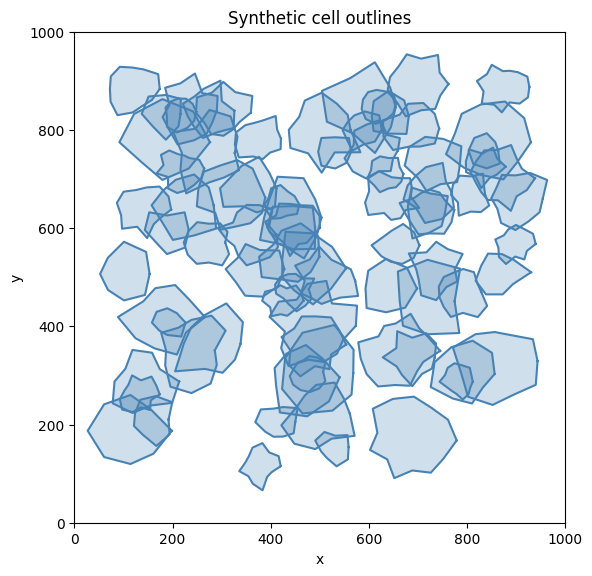

In [3]:
fig, ax = plt.subplots(figsize=(6, 6))
for outline in cell_outlines:
    cm.plot_polygon(ax, outline, facecolor="steelblue", edgecolor="steelblue", facealpha=0.25)
ax.set_xlim(0, FIELD_SIZE)
ax.set_ylim(0, FIELD_SIZE)
ax.set_aspect("equal")
ax.set_title("Synthetic cell outlines")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 2 · Coverage density map

The mapper rasterises each polygon onto a grid and counts how many outlines
overlap each pixel.

In [4]:
mapper = cm.CoverageDensityMapper(field_bounds=BOUNDS, resolution=500)
mapper.add_multiple_polygons(cell_outlines)

stats = mapper.get_coverage_statistics()
print("Coverage statistics:")
for k, v in stats.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

Coverage statistics:
  max_coverage: 5
  mean_coverage: 1.505
  coverage_std: 0.771
  area_covered_fraction: 0.469
  total_pixels: 250000
  covered_pixels: 117368


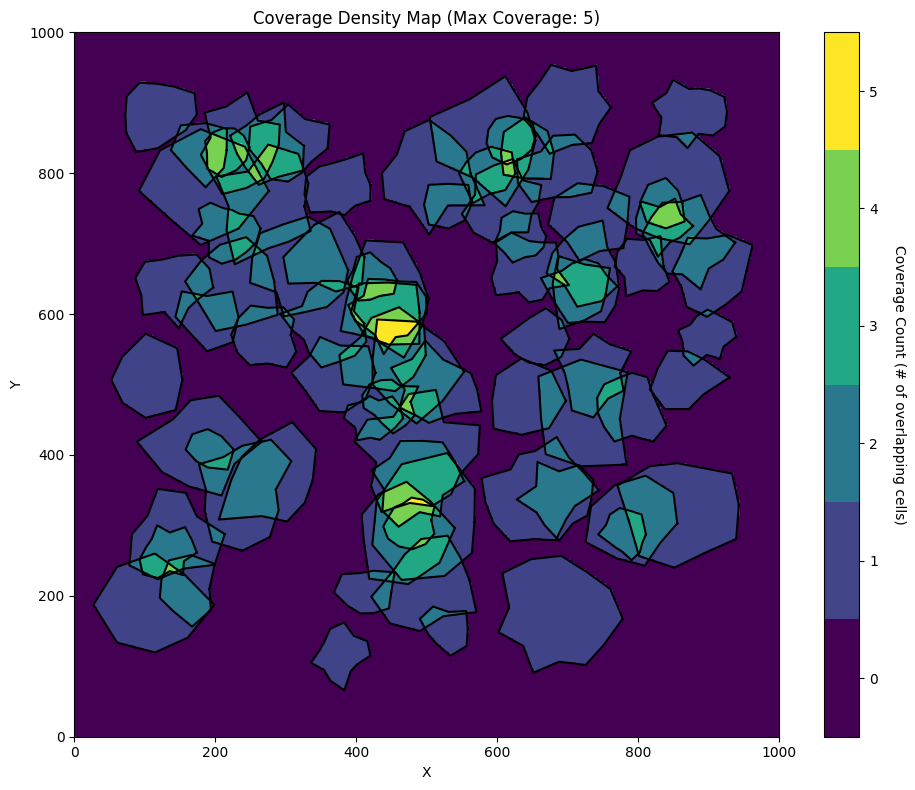

In [5]:
fig, ax, _ = mapper.plot_coverage(plot_cell_outlines=True)
plt.tight_layout()
plt.show()

## 3 · Mosaic metrics

All metrics operate on **cell centroids** rather than full outlines.

In [6]:
centroids = cm.compute_centroids(cell_outlines)   # shape (N, 2)
print(f"Centroids shape: {centroids.shape}")

Centroids shape: (80, 2)


### 3a · Nearest-neighbour distance (NND)

The **regularity index** (RI = mean NND / std NND) quantifies how evenly
spaced cells are.  A Poisson (random) process yields RI ≈ 1.9; ordered
mosaics typically exceed 4.

In [7]:
nnd_stats = cm.nnd_statistics(centroids)

print(f"Mean NND          : {nnd_stats['mean_nnd']:.2f}")
print(f"Std  NND          : {nnd_stats['std_nnd']:.2f}")
print(f"Regularity index  : {nnd_stats['regularity_index']:.2f}")
print(f"CV                : {nnd_stats['cv']:.2f}")

Mean NND          : 48.87
Std  NND          : 28.05
Regularity index  : 1.74
CV                : 0.57


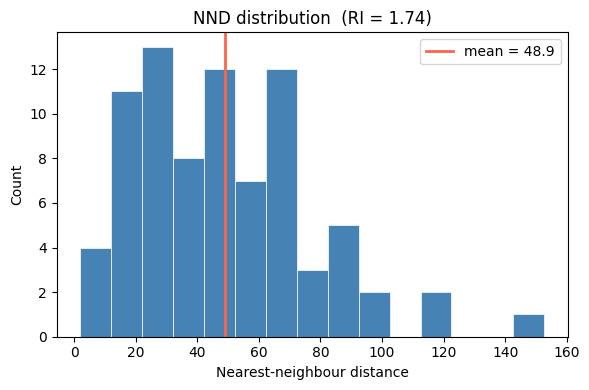

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
nnd = nnd_stats["nnd"]
ax.hist(nnd, bins=15, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(nnd_stats["mean_nnd"], color="tomato", linewidth=2, label=f"mean = {nnd_stats['mean_nnd']:.1f}")
ax.set_xlabel("Nearest-neighbour distance")
ax.set_ylabel("Count")
ax.set_title(f"NND distribution  (RI = {nnd_stats['regularity_index']:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

### 3b · Density Recovery Profile (DRP)

The DRP (Rodieck 1991) shows the local density of neighbours as a function
of distance from each cell, normalised to the global density.
The radius at which the curve first reaches 1 marks the effective
**exclusion zone**.

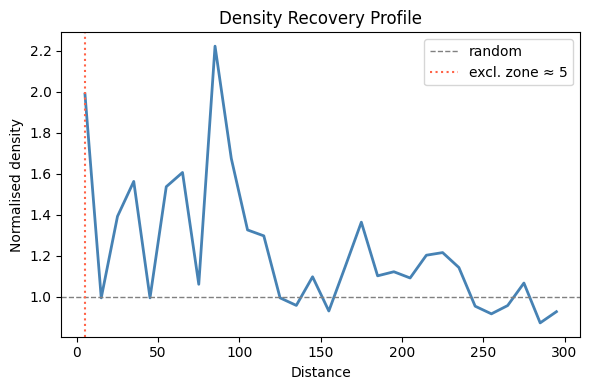

In [9]:
bin_centers, drp = cm.density_recovery_profile(
    centroids,
    field_bounds=BOUNDS,
    n_bins=30,
    max_radius=300,
)

# Estimate exclusion-zone radius: first bin where DRP >= 0.5
exclusion_idx = np.argmax(drp >= 0.5)
exclusion_radius = bin_centers[exclusion_idx] if drp[exclusion_idx] >= 0.5 else None

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bin_centers, drp, color="steelblue", linewidth=2)
ax.axhline(1.0, color="gray", linewidth=1, linestyle="--", label="random")
if exclusion_radius is not None:
    ax.axvline(exclusion_radius, color="tomato", linewidth=1.5, linestyle=":",
               label=f"excl. zone ≈ {exclusion_radius:.0f}")
ax.set_xlabel("Distance")
ax.set_ylabel("Normalised density")
ax.set_title("Density Recovery Profile")
ax.legend()
plt.tight_layout()
plt.show()

### 3c · Voronoi domain analysis

Each cell's Voronoi domain captures its "territory".  The coefficient of
variation (CV) of domain areas is another regularity measure — lower CV
means more regular tiling.

In [10]:
vor_stats = cm.voronoi_analysis(centroids, field_bounds=BOUNDS)

print(f"Interior cells used : {vor_stats['n_interior']} / {N_CELLS}")
print(f"Mean domain area    : {vor_stats['mean_area']:.1f}")
print(f"Std  domain area    : {vor_stats['std_area']:.1f}")
print(f"CV of areas         : {vor_stats['cv_area']:.3f}")
print(f"Regularity index    : {vor_stats['regularity_index']:.2f}")

Interior cells used : 70 / 80
Mean domain area    : 12361.8
Std  domain area    : 16429.0
CV of areas         : 1.329
Regularity index    : 0.75


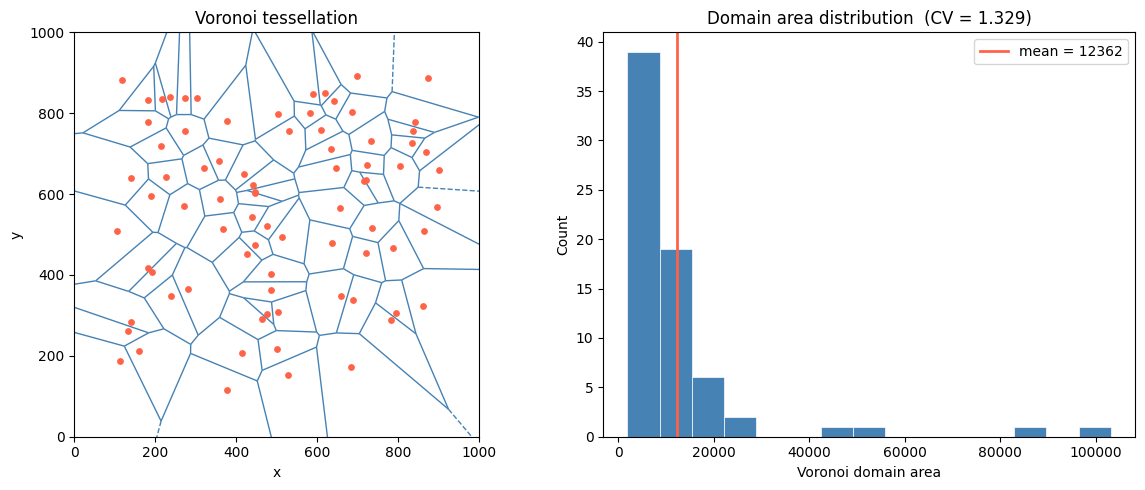

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Voronoi tessellation
ax = axes[0]
vor = Voronoi(centroids)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors="steelblue",
                line_width=1, point_size=3)
ax.scatter(centroids[:, 0], centroids[:, 1], s=15, color="tomato", zorder=3)
ax.set_xlim(0, FIELD_SIZE)
ax.set_ylim(0, FIELD_SIZE)
ax.set_aspect("equal")
ax.set_title("Voronoi tessellation")
ax.set_xlabel("x")
ax.set_ylabel("y")

# Right: domain area histogram
ax = axes[1]
ax.hist(vor_stats["areas"], bins=15, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(vor_stats["mean_area"], color="tomato", linewidth=2,
           label=f"mean = {vor_stats['mean_area']:.0f}")
ax.set_xlabel("Voronoi domain area")
ax.set_ylabel("Count")
ax.set_title(f"Domain area distribution  (CV = {vor_stats['cv_area']:.3f})")
ax.legend()

plt.tight_layout()
plt.show()

## 4 · Compare metrics across polygon types

We generate three mosaics — `irregular`, `convex`, and `concave` — and
compare their NND regularity index and Voronoi CV side by side.

In [12]:
poly_types = ["irregular", "convex", "concave"]
colors     = ["steelblue", "seagreen", "darkorange"]

results = {}
for ptype in poly_types:
    outlines = cm.generate_example_neurons(
        n_cells=N_CELLS, field_size=FIELD_SIZE,
        cell_size_range=(30, 80), polygon_type=ptype, seed=SEED,
    )
    cents = cm.compute_centroids(outlines)
    results[ptype] = {
        "outlines" : outlines,
        "centroids": cents,
        "nnd"      : cm.nnd_statistics(cents),
        "vor"      : cm.voronoi_analysis(cents, field_bounds=BOUNDS),
        "drp"      : cm.density_recovery_profile(cents, BOUNDS, n_bins=30, max_radius=300),
    }

# Summary table
print(f"{'Type':<12} {'NND mean':>10} {'NND RI':>8} {'Vor CV':>8}")
print("-" * 42)
for ptype in poly_types:
    r = results[ptype]
    print(f"{ptype:<12} {r['nnd']['mean_nnd']:>10.2f} "
          f"{r['nnd']['regularity_index']:>8.2f} "
          f"{r['vor']['cv_area']:>8.3f}")

Type           NND mean   NND RI   Vor CV
------------------------------------------
irregular         48.87     1.74    1.329
convex            45.70     1.82    1.971
concave           46.35     2.10    1.912


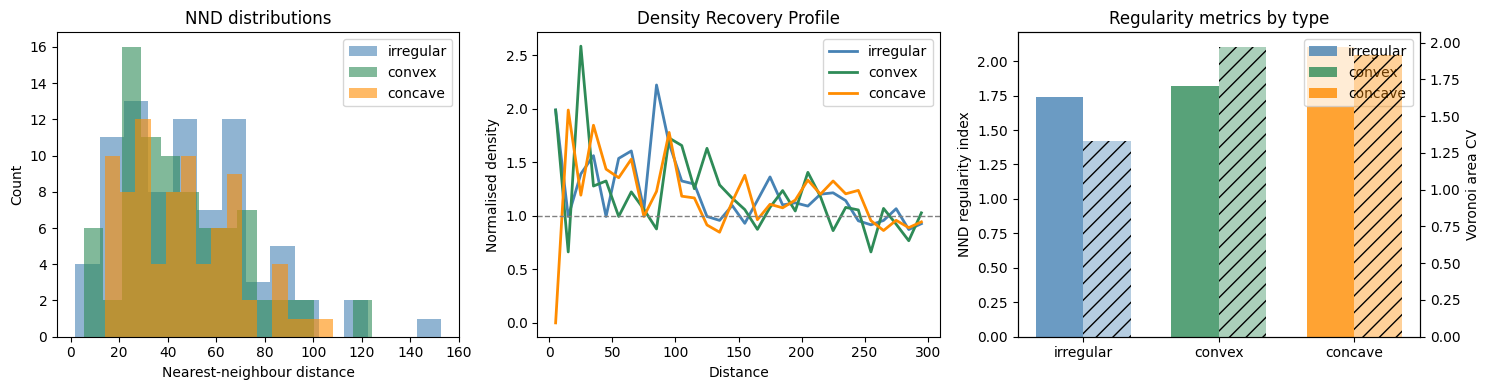

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- NND histograms ---
ax = axes[0]
for ptype, color in zip(poly_types, colors):
    nnd = results[ptype]["nnd"]["nnd"]
    ax.hist(nnd, bins=15, alpha=0.6, color=color, edgecolor="none", label=ptype)
ax.set_xlabel("Nearest-neighbour distance")
ax.set_ylabel("Count")
ax.set_title("NND distributions")
ax.legend()

# --- DRP curves ---
ax = axes[1]
for ptype, color in zip(poly_types, colors):
    centers, drp = results[ptype]["drp"]
    ax.plot(centers, drp, color=color, linewidth=2, label=ptype)
ax.axhline(1.0, color="gray", linewidth=1, linestyle="--")
ax.set_xlabel("Distance")
ax.set_ylabel("Normalised density")
ax.set_title("Density Recovery Profile")
ax.legend()

# --- Voronoi area CV bar chart ---
ax = axes[2]
cv_vals = [results[p]["vor"]["cv_area"] for p in poly_types]
ri_vals = [results[p]["nnd"]["regularity_index"] for p in poly_types]
x = np.arange(len(poly_types))
width = 0.35
bars1 = ax.bar(x - width/2, ri_vals, width, label="NND reg. index", color=colors, alpha=0.8)
ax2 = ax.twinx()
bars2 = ax2.bar(x + width/2, cv_vals, width, label="Voronoi CV", color=colors, alpha=0.4, hatch="//")
ax.set_xticks(x)
ax.set_xticklabels(poly_types)
ax.set_ylabel("NND regularity index")
ax2.set_ylabel("Voronoi area CV")
ax.set_title("Regularity metrics by type")
lines = [plt.Rectangle((0,0),1,1, fc=c, alpha=0.8) for c in colors]
ax.legend(lines, poly_types, loc="upper right")

plt.tight_layout()
plt.show()